In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate
from helper import *
import seaborn as sns
sns.set_style("darkgrid")

## Constants

In [28]:
mu_sun= 1.327e11 ## km^3/s^2  
mu_earth= 3.986e5 ## km^3/s^2  # 3.986e5
mu_mars= 4.2830e4 ## km^3/s^2
mu_moon = 0.4902e4 ## km^3/s^2 Not given in paper

SOI_earth = 923502.24 # km
SOI_mars = 577723.87 # km 577723.87 
SOI_moon = 66300

D_mars = 2.279e8
D_earth = 1.496e8
D_moon = 384400 # km

r_LEO = 463
R_LEO = 6378.2 + r_LEO

w_earth = 1.99177621e-7 # rad/s
w_mars = 1.05850987e-7 # rad/s
w_moon = 2.6653e-6 # rad/s

r_LMO = 200
R_LMO = 3397.0 + r_LMO

## Geocentric Phase

In [29]:
def five_body_ODE_geo( t, state , init_phase, init_moon): # init phase in radians 
    rPEx, rPEy, vPEx, vPEy = state 
    rPE = np.array([rPEx, rPEy])
    rPE_norm = np.linalg.norm(rPE)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])
    r_earth_norm = np.linalg.norm(r_earth)

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    rx_moon = D_moon*np.cos(w_moon*t + init_moon )
    ry_moon = D_moon*np.sin(w_moon*t + init_moon )
    r_moon = np.array([rx_moon, ry_moon])

    # Relative vectors (Spacecraft to Planet)
    rP = rPE + r_earth 
    rP_norm = np.linalg.norm(rP)

    rPM = rP - r_mars       # I think
    rPM_norm = np.linalg.norm(rPM)

    rPMoon = r_moon - rPE
    rPMoon_norm = np.linalg.norm(rPMoon)

    aPEx = (-((mu_sun / (rP_norm**3)) * (rPEx + rx_earth))
    - ((mu_earth / (rPE_norm**3)) * (rPEx))
    - ((mu_mars / (rPM_norm**3)) * (rPEx + rx_earth - rx_mars))
    - ((mu_moon / (rPMoon_norm**3)) * (rPEx - rx_moon))
    + ((mu_sun / (r_earth_norm**3)) * (rx_earth)))

    # aPEx = - ((mu_earth / (rPE_norm**3)) * (rPEx))
#     print(aPEx)
#     print(f"""
# {-((mu_sun / (rP_norm**3)) * (rPEx + rx_earth))}
# {- ((mu_earth / (rPE_norm**3)) * (rPEx))}
# {- ((mu_mars / (rPM_norm**3)) * (rPEx + rx_earth - rx_mars))}
# {+ (mu_sun / (r_earth_norm**3)) * (rx_earth)}
# """)

    aPEy = (-((mu_sun / (rP_norm**3)) * (rPEy + ry_earth)) 
    - ((mu_earth / (rPE_norm**3)) * (rPEy)) 
    - ((mu_mars / (rPM_norm**3)) * (rPEy + ry_earth - ry_mars)) 
    - ((mu_moon / (rPMoon_norm**3)) * (rPEy - ry_moon))
    + ((mu_sun / (r_earth_norm**3)) * (ry_earth)))

    # aPEy = - ((mu_earth / (rPE_norm**3)) * (rPEy))


#     print(f"""
# {-((mu_sun / (rP_norm**3)) * (rPEy + ry_earth))}
# {- ((mu_earth / (rPE_norm**3)) * (rPEy))}
# {- ((mu_mars / (rPM_norm**3)) * (rPEy + ry_earth - ry_mars))}
# {+ (mu_sun / (r_earth_norm**3)) * (ry_earth)}
# """)
    return [vPEx, vPEy, aPEx, aPEy]

# state = four_body_ODE_geo(0,y0 , 30)
# print(state)

## Heliocentric Phase

In [30]:
def four_body_ODE_helio(t, state, init_phase): # init phase in radians 
    rPx, rPy, vPx, vPy = state 
    rP = np.array([rPx, rPy])
    rP_norm = np.linalg.norm(rP)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    rPM = rP - r_mars       # I think
    rPM_norm = np.linalg.norm(rPM)

    rPE = rP = r_earth
    rPE_norm = np.linalg.norm(rPE)

    aPx = (-((mu_sun / (rP_norm**3)) * (rPx))
    - ((mu_earth / (rPE_norm**3)) * (rPx - rx_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPx - rx_mars)))

    aPy = (-((mu_sun / (rP_norm**3)) * (rPy))
    - ((mu_earth / (rPE_norm**3)) * (rPy - ry_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPy - ry_mars)))

    return [vPx, vPy, aPx, aPy]

four_body_ODE_helio(0.5,[10,10,10,10], 10)

[10, 10, np.float64(-469165349.3172742), np.float64(-469165349.3172742)]

## Constraints

In [122]:
def g1(rPMx, rPMy, debug = False): # Correct Height
    con = rPMx**2 + rPMy**2 - R_LMO**2

    if debug:
        print(f"""
{rPMx**2 + rPMy**2 = }
{R_LMO**2 = }
{con = }""")
        
    return con


def g3(rPMx, rPMy, vPMx, vPMy, orientation = "clockwise" ,debug = False): # Correct Direction
    LHS = np.sqrt(vPMx**2 + vPMy**2)
    RHS = (rPMx*vPMy - rPMy*vPMx)/R_LMO

    if debug:
        print(f"""
{LHS = }
{RHS = }
""")
    if orientation == "clockwise":
        return LHS + RHS
    
    if orientation == "counterclockwise":
        return LHS - RHS

## Planetocentric Phase

In [32]:
def four_body_ODE_mars( t, state, init_phase): # init phase in radians 
    rPMx, rPMy, vPMx, vPMy = state 
    rPM = np.array([rPMx, rPMy])
    rPM_norm = np.linalg.norm(rPM)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])
    r_mars_norm = np.linalg.norm(r_mars)

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    rPE = rP = r_earth
    rPE_norm = np.linalg.norm(rPE)

    rP = rPE + r_earth 
    rP_norm = np.linalg.norm(rP)

    aPMx = -((mu_sun / (rP_norm**3)) * (rPMx + rx_mars))
    - ((mu_earth / (rPE_norm**3)) * (rPMx + rx_mars - rx_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPMx))
    + ((mu_sun / (r_mars_norm**3)) * (rx_mars))

    aPMy = -((mu_sun / (rP_norm**3)) * (rPMy + ry_mars))
    - ((mu_earth / (rPE_norm**3)) * (rPMy + ry_mars - ry_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPMy))
    + ((mu_sun / (r_mars_norm**3)) * (ry_mars))

    return [vPMx, vPMy, aPMx, aPMy]

four_body_ODE_mars(0.5,[10,10,10,10], 10)

[10, 10, np.float64(9.473913779051102e-07), np.float64(6.142515115038357e-07)]

## Integrate Functions

In [33]:
class Trajectory:
    def __init__(self, yPE_geo, t_geo, yP_helio, t_helio, yPM_mars, t_mars):
        self.yPE_geo = yPE_geo
        self.t_geo = t_geo
        self.yP_helio = yP_helio
        self.t_helio = t_helio
        self.yPM_mars = yPM_mars
        self.t_mars = t_mars

In [66]:
def integrate_geo(ys,ts, init_phase, init_moon,dt = 10,step = 0):
    solver = integrate.ode(five_body_ODE_geo)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(ys, ts[0])
    solver.set_f_params(init_phase, init_moon)
    # print(solver.t, ts)

    while solver.successful():
        solver.integrate(solver.t + dt)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        # print(ts)
        step += 1
        # print(ys[step,:2 ])
        # print(solver.get_return_code())
        if np.linalg.norm(ys[step,:2]) > SOI_earth:
            print(f"""
Exitted SOI of Earth at
rPE = {solver.y[0]} , {solver.y[1]} km
vPE = {solver.y[2] , solver.y[3]} km/s
t = {solver.t} s \n""")
            return ys, ts, True
        
        if (solver.t/(60*60*24)) > 50:
            print("""
Failed to exit Earth SOI""")
            return ys, ts, False
        

    print(ys)
    print(ts)


In [106]:
def integrate_helio(ys, ts,init_phase, dt = 300, step = 0):
    def get_rPM_norm(rP, t, debug = False): # Im gonna fucking crash out
        rx_mars = D_mars*np.cos(w_mars*t + init_phase)
        ry_mars = D_mars*np.sin(w_mars*t + init_phase)
        r_mars = np.array([rx_mars, ry_mars])
        rPM = rP - r_mars      # I think
        rPM_norm = np.linalg.norm(rPM)
        if debug:
            print(f"""
    {rx_mars = }
    {ry_mars = }
    {r_mars = }
    {rPM = }
    {rPM_norm = }""")
        return rPM_norm
    
    solver = integrate.ode(four_body_ODE_helio)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(ys, ts[0])
    solver.set_f_params(init_phase)
    print(ys[:2])
    distance_from_mars = [get_rPM_norm(ys[:2], ts[0])]
    while solver.successful() and step < (100000*8):
        solver.integrate(solver.t + dt)
        # print(solver.t)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        # print(get_rPM_norm([solver.y[0],solver.y[1]], solver.t), solver.t/(60*60*24) )
        distance_from_mars = np.vstack((distance_from_mars, get_rPM_norm([solver.y[0],solver.y[1]], solver.t)))
        step += 1
        # print(f"{solver.y[0]:e} {solver.y[1]} {solver.t / (24*60*60)}")
        # print(f"{get_rPM_norm([solver.y[0],solver.y[1]], solver.t):e} {SOI_mars:e} {(get_rPM_norm([solver.y[0],solver.y[1]], solver.t) - SOI_mars):e} ")
        # if (get_rPM_norm([solver.y[0],solver.y[1]], solver.t) - SOI_mars) < 5e5:
        #     dt = 300

        if get_rPM_norm([solver.y[0],solver.y[1]], solver.t) < SOI_mars:
            print(f"""
Enterred SOI of Mars at
rP = {solver.y[0]:e} , {solver.y[1]:e} km
vP = {solver.y[2] , solver.y[3]} km/s
t = {solver.t} s\n""")
            return ys, ts, True, 0 
        
#         if solver.y[0] < 0:
#             if get_rPM_norm([ys[-1,0],ys[-1,1]], ts[-1]) < get_rPM_norm([ys[-2,0],ys[-2,1]], ts[-2]):
#                 print(f"""
# {get_rPM_norm([ys[-1,0],ys[-1,1]], ts[-1]) = }
# {get_rPM_norm([ys[-2,0],ys[-2,1]], ts[-2]) = }
# Swing and a miss """)
#                 return -1, ts

        if (solver.t/(60*60*24)) > 300:
            print(f"""
Failed to Enter Mars SOI
Closest to Mars at {np.min(distance_from_mars)}""")
            return ys, ts, False, np.min(distance_from_mars)

    print(ys, ts)

In [142]:
def integrate_mars(ys, ts,init_phase, dt = 60, step = 0):
    solver = integrate.ode(four_body_ODE_mars)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(ys, ts[0])
    solver.set_f_params(init_phase)

    while solver.successful():
        solver.integrate(solver.t + dt)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        step += 1
        # print(ys[step,:2 ])
        # print(solver.get_return_code())
        if np.linalg.norm(ys[step,:2]) < R_LMO: # Not sure if this is a good way of doing it
            print(f"""
Reached desired height of Mars orbit at
rPM = {solver.y[0]} , {solver.y[1]} km
vPM = {solver.y[2] , solver.y[3]} km/s
t = {solver.t} s
{abs(g1(solver.y[0],solver.y[1],debug= True)) = }
{abs(g3(solver.y[0],solver.y[1],solver.y[2],solver.y[3], orientation="counterclockwise")) = }\n""")
            return ys, ts, abs(g1(solver.y[0],solver.y[1], debug = True)) + abs(g3(solver.y[0],solver.y[1],solver.y[2],solver.y[3], orientation="counterclockwise",debug = True )*10000000), (np.sqrt(solver.y[2]**2 + solver.y[3]**2) - np.sqrt(mu_mars/R_LMO))
            # return ys, ts, g(solver.y[0],solver.y[1],solver.y[2],solver.y[3], deltaV_LMO, debug= True)
        
        if np.linalg.norm(ys[step,:2]) > np.linalg.norm(ys[step - 1,:2]):
            print(f"""
Swing and a miss
Closest distance = {np.linalg.norm(ys[step - 1,:2])} km""")
            return ys, ts, abs(g1(solver.y[0],solver.y[1], debug= True))  + abs(g3(solver.y[0],solver.y[1],solver.y[2],solver.y[3], orientation="counterclockwise",debug = True)*10000000), (np.sqrt(solver.y[2]**2 + solver.y[3]**2) - np.sqrt(mu_mars/R_LMO))
            # return ys, ts, g(solver.y[0],solver.y[1],solver.y[2],solver.y[3], deltaV_LMO)
        if (solver.t/(60*60*24)) > 400:
            print(f"Failed to solve for constraints in time")
            return -1, ts, np.inf

    # if g(solver.y[0], solver.y[1], solver.y[2], solver.y[3], deltaV_LMO):
    #     break

# print(ys)
# print(ts)

## Simulate Function

In [134]:
def simulate(thetaPE0, init_phase, init_moon, deltaV_LEO): # Give angles in degrees
    # Success Flags
    geo_success = False
    helio_success = False
    mars_success = False

    # Initialize trajectory
    yPE_geo = t_geo = yP_helio = t_helio = yPM_mars = t_mars = 0

    ############GEOCENTRIC#####################
    # timestep 
    dt = 10.0

    # Parameters
    thetaPE0 = np.deg2rad(thetaPE0)
    init_phase = np.deg2rad(init_phase)
    init_moon = np.deg2rad(init_moon)

    deltaV_LEO = deltaV_LEO
    deltaV_LMO = -1.0 # Sili big number
    print(deltaV_LEO, thetaPE0)

    # IC for geocentric phase
    rPEx0 = R_LEO*np.cos(thetaPE0) # thetaPE0 to be perscribed
    rPEy0 = R_LEO*np.sin(thetaPE0) # thetaPE0 to be perscribed

    vPEx0 = (-(np.sqrt(mu_earth/R_LEO) + deltaV_LEO)) * np.sin(thetaPE0)
    vPEy0 = (np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.cos(thetaPE0)
    # print(np.sqrt(mu_earth/R_LEO) * np.sin(thetaPE0))
    # print(vPEy0)

    y0 =np.array([rPEx0, rPEy0, vPEx0, vPEy0], None)
    ys = y0
    ts = [0]
    print(ys, ts)
    yPE_geo, t_geo, geo_success = integrate_geo(ys, ts, init_phase, init_moon, dt=dt)
    if geo_success == False:
        objective = 20e50

    #################HELIOCENTRIC#####################
    
    if geo_success:
        # timestep 
        dt = 60*30

        t1 = t_geo[-1]
        rPEx1, rPEy1, vPEx1, vPEy1 = yPE_geo[-1]
        # Earth Pos and Vel
        rx_earth1 = D_earth*np.cos(w_earth*t1)
        ry_earth1 = D_earth*np.sin(w_earth*t1)

        vx_earth1 = -w_earth*D_earth*np.sin(w_earth*t1)
        vy_earth1 = w_earth*D_earth*np.cos(w_earth*t1)
    
        # initial conditions
        rPx1 = rx_earth1 + rPEx1 
        rPy1 = ry_earth1 + rPEy1 

        vPx1 = vx_earth1 + vPEx1 
        vPy1 = vy_earth1 + vPEy1 

        y1 =np.array([rPx1[0], rPy1[0], vPx1[0], vPy1[0]])

        ys = y1
        ts = t1
        yP_helio, t_helio, helio_success, closest_to_mars = integrate_helio(ys, ts, init_phase, dt = dt)
        if helio_success == False:
            objective = closest_to_mars**2
        # print(f"{yP_helio} test")
        # if np.size(yP_helio) == 1:
        #     objective = dist_from_mars**2
        #     helio_success = False
        # else:
        #     helio_success = True

    ###################MARSCENTRIC########################
    if helio_success:
        # timestep
        dt = 10

        rPx2, rPy2, vPx2, vPy2 = yP_helio[-1]
        t2 = t_helio[-1]

        # Mars Pos and Vel
        rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
        ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

        vx_mars2 = -w_mars*D_mars*np.sin(w_mars*t2 + init_phase)
        vy_mars2 = w_mars*D_mars*np.cos(w_mars*t2 + init_phase)

        # Initial Conditions
        rPMx2 = rPx2 - rx_mars2
        rPMy2 = rPy2 - ry_mars2

        vPMx2 = vPx2 - vx_mars2
        vPMy2 = vPy2 - vy_mars2

        y2 =np.array([rPMx2[0], rPMy2[0], vPMx2[0], vPMy2[0]], None)

        ys = y2
        ts = t2

        # print(ys , ts)
        yPM_mars, t_mars, objective, deltaV_LMO = integrate_mars(ys, ts,init_phase ,dt = dt)
        if np.size(yPM_mars) == 1:
            objective = np.inf
            mars_success = False
        else:
            mars_success = True
            print(f"""
{deltaV_LEO = }
{deltaV_LMO = }""")
    return objective, Trajectory(yPE_geo, t_geo, yP_helio, t_helio, yPM_mars, t_mars), deltaV_LMO




In [87]:
init_phase = 176.544391 - np.rad2deg((w_mars * 257.443*60*60*24))
init_phase

np.float64(41.64425905384314)

In [131]:
thetaPE0 = -88.194
deltaV_LEO = 3.469766
init_phase = init_phase
init_moon = 0

result, trajectory, deltaV_LMO = simulate(thetaPE0, init_phase, init_moon , deltaV_LEO)

TypeError: 'float' object is not subscriptable

In [149]:
initial_guess = [3.5,271.806]


def wrapped_simulate(x):
    init_phase = 44
    init_moon = 43.940
    deltaV_LEO, thetaPE0 = x
    objective = simulate(thetaPE0, init_phase,init_moon ,deltaV_LEO)[0]
    print(f"{objective}")
    return objective

soln = optimize.minimize(wrapped_simulate,initial_guess, method = "Nelder-Mead", bounds=((0,10),(0,359)))
print(f"""DeltaV_LEO = {soln.x[0]} km/s  thetaPE0 = {soln.x[1]} degrees
{soln.status}
{soln.message}
{soln}""")

3.5 4.743909626675707
[ 2.15603339e+02 -6.83780174e+03  1.11275971e+01  3.50865260e-01] [0]

Exitted SOI of Earth at
rPE = 854947.6450779268 , 349214.18173331843 km
vPE = (np.float64(2.02072129072492), np.float64(-0.02294690183991107)) km/s
t = 417810.0 s 

[1.49937234e+08 1.27843227e+07]

Failed to Enter Mars SOI
Closest to Mars at 67616683.12513685
4572015836845167.0
3.6750000000000003 4.743909626675707
[ 2.15603339e+02 -6.83780174e+03  1.13025101e+01  3.56380459e-01] [0]

Exitted SOI of Earth at
rPE = 482972.14349655143 , 787152.5052932827 km
vPE = (np.float64(1.7279363442189184), np.float64(3.0834581598991284)) km/s
t = 242430.0 s 

[1.49908602e+08 8.00802566e+06]

Failed to Enter Mars SOI
Closest to Mars at 25351034.73854736
642674962315035.0
3.5 4.981105108009492
[ 1.81629658e+03 -6.59568678e+03  1.07335877e+01  2.95577691e+00] [0]

Exitted SOI of Earth at
rPE = 226501.2573523233 , 895314.4897259847 km
vPE = (np.float64(0.6373194161423309), np.float64(2.788565138623864)) km/s
t =

In [153]:
thetaPE0 = soln.x[1]
deltaV_LEO = soln.x[0]
init_phase = 44
init_moon = 43.940

result, trajectory, deltaV_LMO = simulate(thetaPE0, init_phase, init_moon , deltaV_LEO)

3.5182975211642926 5.153306804723238
[ 2.91961679e+03 -6.18690999e+03  1.00849064e+01  4.75909009e+00] [0]

Exitted SOI of Earth at
rPE = 76882.771324424 , 920298.8723170162 km
vPE = (np.float64(0.17090656277471267), np.float64(2.929609555667927)) km/s
t = 283970.0 s 

[1.49437655e+08 9.37723428e+06]

Enterred SOI of Mars at
rP = -2.247153e+08 , 3.721024e+07 km
vP = (np.float64(-4.24353211992644), np.float64(-21.066689004511762)) km/s
t = 20850770.0 s


rPMx**2 + rPMy**2 = np.float64(12938408.996794436)
R_LMO**2 = 12938409.0
con = np.float64(-0.003205563873052597)

Reached desired height of Mars orbit at
rPM = 3596.9917720600024 , 7.693408027662372 km
vPM = (np.float64(-0.005962346604836464), np.float64(2.68592482207255)) km/s
t = 21063970.0 s
abs(g1(solver.y[0],solver.y[1],debug= True)) = np.float64(0.003205563873052597)
abs(g3(solver.y[0],solver.y[1],solver.y[2],solver.y[3], orientation="counterclockwise")) = np.float64(9.144626833545999e-09)


rPMx**2 + rPMy**2 = np.float64(12938408

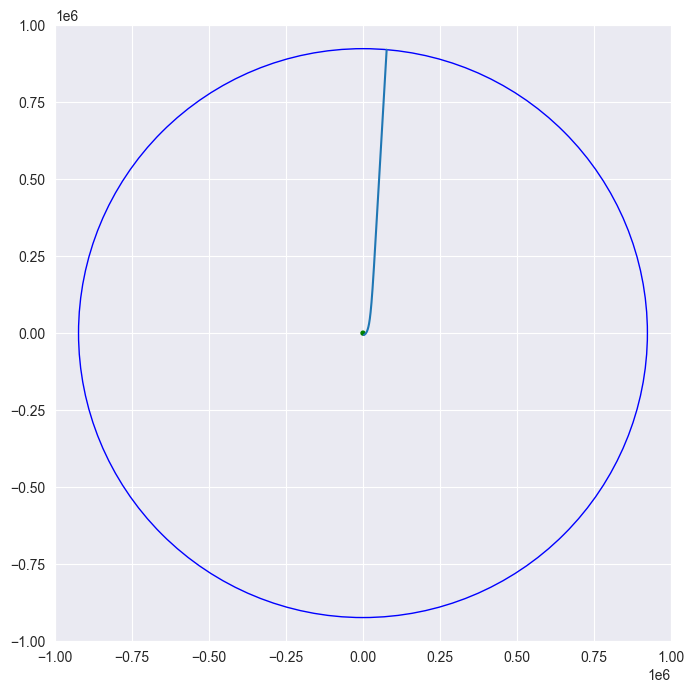

In [157]:
def plot_geo_wide(yPE_geo):
    rs = yPE_geo[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    fig, ax = plt.subplots(figsize = (13,8))
    ax.set_aspect(1)
    plt.xlim(-1e6,+1e6)
    plt.ylim(-1e6,+1e6)

    plt.plot(rsx, rsy)
    earth = plt.Circle((0,0), 6378.2, color = "g")
    earthSOI = plt.Circle((0, 0), SOI_earth, color='b', fill=False)

    ax.add_patch(earth)
    ax.add_patch(earthSOI)

    plt.show()

plot_geo_wide(trajectory.yPE_geo)

2.20707458420999


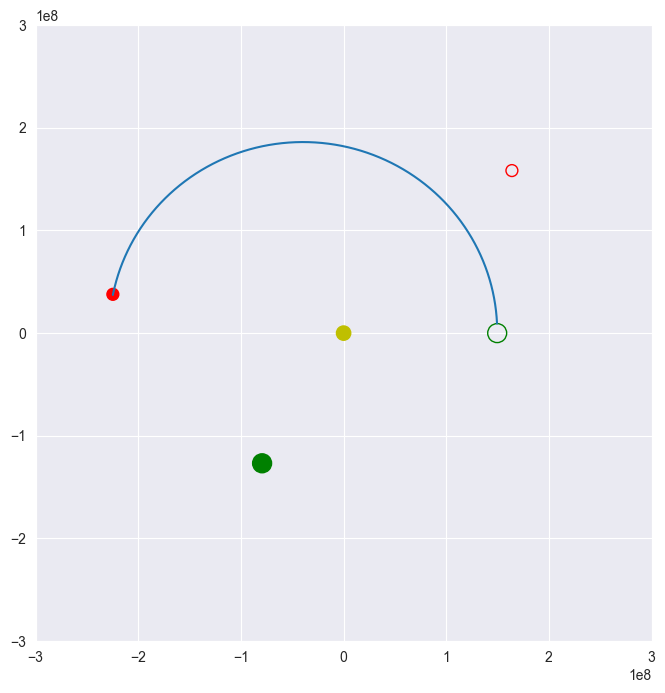

In [156]:
def plot_wide_helio(yP_helio, t_helio, init_phase):
    init_phase = np.deg2rad(init_phase)
    t1 = 0
    t2 = t_helio[-1][0]

    rs = yP_helio[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    # Pos of Earth at t1
    rx_earth1 = D_earth*np.cos(w_earth*t1)
    ry_earth1 = D_earth*np.sin(w_earth*t1)

    # Pos of Mars at t1
    rx_mars1 = D_mars*np.cos(w_mars*t1 + init_phase)
    ry_mars1 = D_mars*np.sin(w_mars*t1 + init_phase)

    # Pos of Mars at t2
    rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
    ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

    print((w_mars*t2))
    # Pos of Earth at t2 
    rx_earth2 = D_earth*np.cos(w_earth*t2)
    ry_earth2 = D_earth*np.sin(w_earth*t2)


    fig, ax = plt.subplots(figsize = (13,8))

    # Scale for Sun and planet SOI visualisation
    scaling_factor = 10
    ax.set_aspect(1)
    plt.xlim(-3e8,+3e8)
    plt.ylim(-3e8,+3e8)

    plt.plot(rsx, rsy)

    earth1SOI = plt.Circle((rx_earth1, ry_earth1), SOI_earth*scaling_factor, color='g', fill=False)
    earth2SOI = plt.Circle((rx_earth2, ry_earth2), SOI_earth*scaling_factor, color='g', fill=True)

    mars1SOI = plt.Circle((rx_mars1, ry_mars1), SOI_mars*scaling_factor, color='r', fill=False)
    mars2SOI = plt.Circle((rx_mars2, ry_mars2), SOI_mars*scaling_factor, color='r', fill=True)
    # mars3SOI = plt.Circle((rx_mars3, ry_mars3), SOI_mars*1, color='y', fill=False)

    Sun = plt.Circle((0, 0), 696340*scaling_factor, color='y', fill=True)

    ax.add_patch(earth1SOI)
    ax.add_patch(earth2SOI)

    ax.add_patch(mars1SOI)
    ax.add_patch(mars2SOI)
    # ax.add_patch(mars3SOI)

    ax.add_patch(Sun)
    
    plt.show()

plot_wide_helio(trajectory.yP_helio, trajectory.t_helio, init_phase)

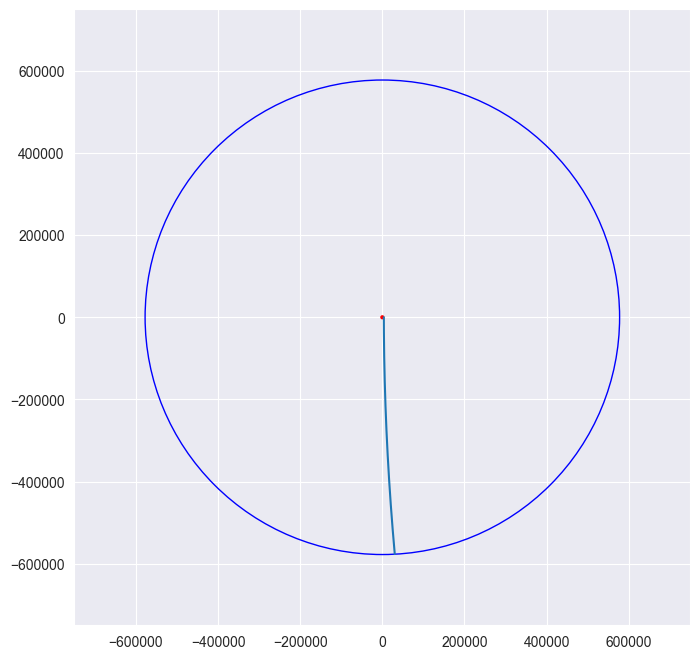

In [155]:
def plot_mars_wide(yPM_mars):
    rs = yPM_mars[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    fig, ax = plt.subplots(figsize = (13,8))
    ax.set_aspect(1)
    plt.xlim(-0.75e6,+.75e6)
    plt.ylim(-.75e6,+.75e6)

    plt.plot(rsx, rsy)
    mars = plt.Circle((0,0), 3397.0, color = "r")
    marsSOI = plt.Circle((0, 0), SOI_mars, color='b', fill=False)

    ax.add_patch(mars)
    ax.add_patch(marsSOI)

    plt.show()

plot_mars_wide(trajectory.yPM_mars)

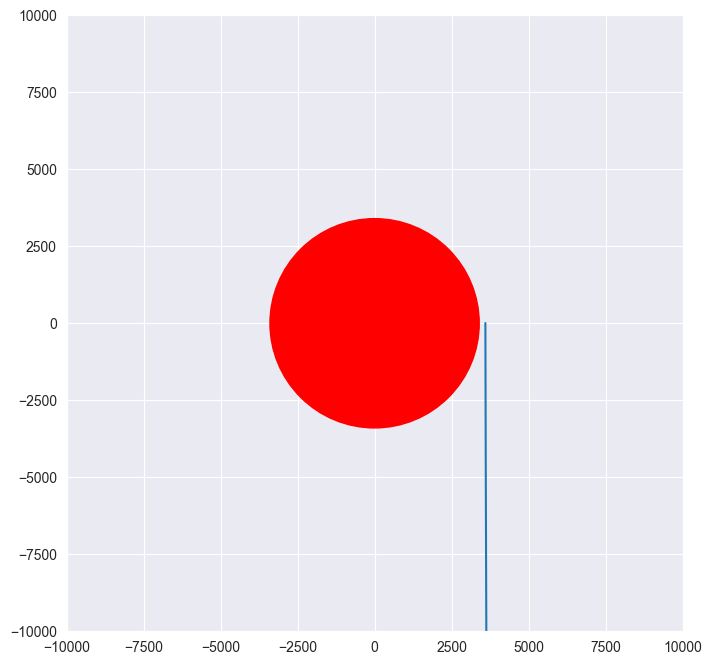

In [154]:
def plot_mars_tight(yPM_mars):
    rs = yPM_mars[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    fig, ax = plt.subplots(figsize = (13,8))
    ax.set_aspect(1)
    plt.xlim(-1e4,+1e4)
    plt.ylim(-1e4,+1e4)

    plt.plot(rsx, rsy)
    mars = plt.Circle((0,0), 3397.0, color = "r")
    marsSOI = plt.Circle((0, 0), SOI_mars, color='b', fill=False)

    ax.add_patch(mars)
    ax.add_patch(marsSOI)

    plt.show()

plot_mars_tight(trajectory.yPM_mars)

In [ ]:
thetaPE0 = -88.194
deltaV_LEO = 3.469766
init_phase = 41.605566
init_moon = 43.940

result, trajectory2, deltaV_LMO = simulate(thetaPE0, init_phase, init_moon , deltaV_LEO)